In [80]:
import os 
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

1. Isolation Forest

In [19]:
# Get the current directory
current_directory = os.getcwd()

# Get the source file path
file_path = f'{current_directory}/datasets/processed'
file = f"{file_path}/processed_training_data.csv"
df = pd.read_csv(file, header=0)
df

,sus,evil,processId_freq,threadId_freq,parentProcessId_freq,userId_freq,mountNamespace_freq,eventId_freq,userId_binary,stackAddresses_len,stackAddresses_jump_std,stackAddresses_unique_ratio,returnValue_is_error,argsNum,args_has_path,mountNamespace_binary
0,1,0,188,3,9345,188,188,169,1,2,0.0,1.0,0,5,0,0
1,1,0,188,3,9345,188,188,26651,1,1,0.0,1.0,0,1,0,0
2,1,0,188,3,9345,188,188,154,1,0,0.0,0.0,0,0,0,0
3,1,0,50,50,50,94482,94865,192,1,0,0.0,0.0,0,2,1,1
4,1,0,50,50,50,94482,94865,24073,1,2,0.0,1.0,0,4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763139,0,0,262,262,262,15651,15649,70,1,0,0.0,0.0,0,1,0,1
763140,0,0,262,262,262,15651,15649,26,1,0,0.0,0.0,0,2,0,1
763141,0,0,262,262,262,15651,15649,31,1,0,0.0,0.0,0,0,0,1
763142,0,0,22,22,790,9,15649,31,1,0,0.0,0.0,0,0,0,1


In [21]:
X_train = df.drop(columns=['sus', 'evil'])
y_train = df['evil']

In [87]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest

numeric_features = ["stackAddresses_len", "stackAddresses_jump_std","argsNum"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numeric_features)
    ],
    remainder="passthrough"
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("iforest", IsolationForest(
            n_estimators=300,
            contamination="auto",
            max_features=0.7,
            random_state=42
        ))
    ]
)



In [88]:
# Perform fit on X and returns labels for X.
y_pred = model.fit_predict(X_train, y_train)

# Returns -1 for outliers and 1 for inliers.
# change -1 to 0:
y_pred = np.where(y_pred == -1, 1, 0)

# Get unique values and their counts in y_pred
unique_values, counts = np.unique(y_pred, return_counts=True)
print(f"Unique values: {unique_values}")
print(f"Counts of each value: {counts}")

# Get unique values and their counts in y_train
unique_values, counts = np.unique(y_train, return_counts=True)
print(f"Unique values: {unique_values}")
print(f"Counts of each value: {counts}")

Unique values: [0 1]
Counts of each value: [524967 238177]
Unique values: [0]
Counts of each value: [763144]


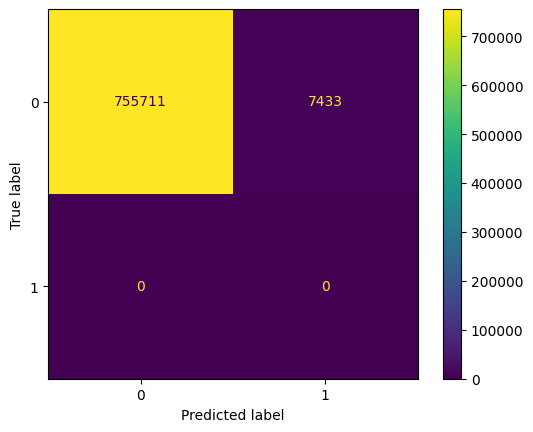

In [64]:
cm = confusion_matrix(y_train, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=[0,1])
disp.plot()
plt.show()


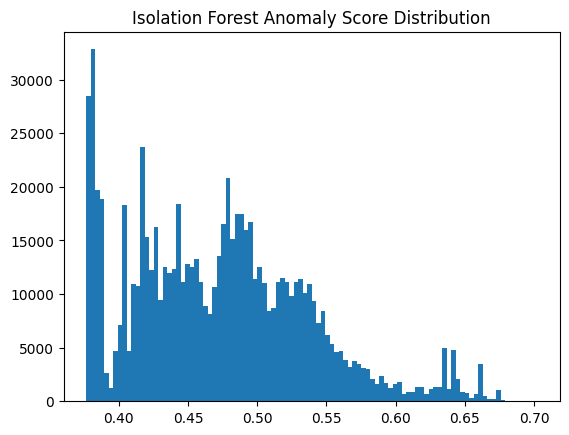

In [ ]:
anomaly_scores = model.score_samples(X_train)

anomaly_scores = -anomaly_scores  # Invert scores so that higher values indicate more anomalous instances

plt.hist(anomaly_scores, bins=100)
plt.title("Isolation Forest Anomaly Score Distribution")
plt.show()

nan